# PyDESeq2 differential expression analysis: ERBB2 OE vs WT, sham and MI

**Data**

3 animals for each experimental group were used (Control, mOSM, mLIF and hOSM).
Adult murine cardiomyocytes were isollated and cultured using normoxic conditions. The cultures were treated with recomninant mOSM, mLIF or hOSM(mOSM with substitution of the AB loop for the human sequence), or PBS as control. 
The cultures were incubated for 24h, then RNA was isollated and prepared for RNA-seq. 
hOSM was compared to mOSM and mLIF because hOSM activates OSMR and LIFR, while mOSM and mLIF can only activate their respective receptors.

https://www.mdpi.com/1422-0067/23/1/353

**Design**
The samplesheet has one factors, `condition` (Control / mOSM / mLIF / hOSM), and the model `~ condition` is fitted **once** on all 12 samples, so dispersions are estimated with all the data. Four contrasts are then extracted:
- `mOSM vs Control`
- `mLIF vs Control`
- `hOSM vs Control`
- `hOSM vs mOSM` (not used for Corneto)

log2FC is always `OE / WT`, so a positive value means higher in the experimental group. Each contrast is exported as its own table, ready for the CORNETO notebook.

**Inputs**
- Raw (un-normalised) counts, genes x samples (nf-core `salmon.merged.gene_counts.tsv`). Salmon counts are non-integer and are rounded.
- `samplesheet.csv` with `sample` and `condition` columns.

**Conventions kept from the AXL analysis**
- Genes with fewer than 30 reads across all samples are removed before fitting.
- Significance threshold: adjusted p < 0.05.
- `stat` is the Wald statistic from the un-shrunk model (the CORNETO notebook runs decoupler on `stat`). LFC shrinkage is not applied.

**Things to check**
- Gene identifiers: the CORNETO notebook expects **mouse gene symbols**. nf-core tables have `gene_id` (Ensembl) and `gene_name`; the loader below uses `gene_name` as index.
- Use the PCA in step 5 to spot outlier samples. Document any exclusion in the config cell rather than editing the count file.

In [3]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print('pydeseq2', pydeseq2.__version__)

pydeseq2 0.5.0


## 1. Configuration (edit this cell only)

In [2]:
root_dir = '/mnt/sds-hd/sd22b002/projects/ines/axl_networks'
project_dir = f'{root_dir}/results/osm_lif'    # nf-core run output

dataset_id = 'GSE185305_OSM_LIF'   # prefix for output file names
counts_file = f'{project_dir}/star_salmon/salmon.merged.gene_counts.tsv'
counts_sep = '\t'
counts_orientation = 'genes_x_samples'   # or 'samples_x_genes'
gene_name_col = 'gene_name'      # nf-core: symbols column next to the Ensembl gene_id index; None if absent

# --- sample annotation ---------------------------------------------------
metadata_file = f'{root_dir}/data/downloads/GSE185305_OSM_LIF/samplesheet.csv'
metadata_sep = ','
metadata_index_col = 'sample'    # column with sample IDs matching the count matrix columns
group_col = 'condition'

# name -> (numerator group, reference group); log2FC = numerator / reference
contrasts = {
    'hosm_vs_control': ('hOSM', 'Control'),
    'mosm_vs_control': ('mOSM', 'Control'),
    'lif_vs_control': ('mLIF', 'Control'),
    'hosm_vs_mosm': ('hOSM', 'mOSM'),

}
covariates = []                  # extra design columns present in the metadata, e.g. ['batch']
exclude_samples = []             # sample IDs to drop (document why, e.g. PCA outlier)

# --- model / filtering ---------------------------------------------------
min_total_counts = 30            # same filter as the AXL analysis (sum over all samples)
alpha = 0.05
n_cpus = 2

# --- output --------------------------------------------------------------
results_dir = f'{root_dir}/results/osm_lif/pydeseq2'
figures_dir = f'{root_dir}/figures'
os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

## 2. Load counts and metadata

In [4]:
counts = pd.read_csv(counts_file, sep=counts_sep, index_col=0)
if counts_orientation == 'genes_x_samples':
    # nf-core tables: Ensembl gene_id is the index, gene_name a separate column
    if gene_name_col is not None and gene_name_col in counts.columns:
        counts = counts.set_index(gene_name_col)
    counts = counts.T          # PyDESeq2 wants samples x genes
elif counts_orientation != 'samples_x_genes':
    raise ValueError("counts_orientation must be 'genes_x_samples' or 'samples_x_genes'")
counts.index = counts.index.astype(str)
counts.columns = counts.columns.astype(str)

# sample annotation, with the two factors merged into one group factor
metadata = pd.read_csv(metadata_file, sep=metadata_sep, index_col=metadata_index_col)
metadata.index = metadata.index.astype(str)

# consistency checks
missing_meta = counts.index.difference(metadata.index)
missing_counts = metadata.index.difference(counts.index)
if len(missing_meta) or len(missing_counts):
    print('In counts but not metadata (dropped):', list(missing_meta))
    print('In metadata but not counts (dropped):', list(missing_counts))
keep = counts.index.intersection(metadata.index).difference(exclude_samples)
counts, metadata = counts.loc[keep], metadata.loc[keep]

# duplicated gene symbols: sum them
if counts.columns.duplicated().any():
    print(f'Summing {counts.columns.duplicated().sum()} duplicated gene columns')
    counts = counts.T.groupby(level=0).sum().T

# raw counts must be non-negative
counts = counts.apply(pd.to_numeric)
if counts.isna().any().any() or (counts < 0).any().any():
    raise ValueError('Counts contain NaN or negative values')
if (counts % 1 != 0).any().any():
    print('Non-integer counts found (salmon expected counts): rounding')
counts = counts.round().astype(int)

metadata = metadata[[group_col] + covariates].copy()
levels = set(metadata[group_col].unique())
needed = {g for pair in contrasts.values() for g in pair}
assert needed <= levels, f'missing groups: {needed - levels}; levels found: {levels}'

print(f'{counts.shape[0]} samples x {counts.shape[1]} genes')
print(metadata.groupby(group_col).size())

Summing 306 duplicated gene columns
Non-integer counts found (salmon expected counts): rounding
12 samples x 78028 genes
condition
Control    3
hOSM       3
mLIF       3
mOSM       3
dtype: int64


## 3. Filter low-count genes

In [5]:
# Keep only the groups used in the contrasts
metadata = metadata[metadata[group_col].isin(needed)]
counts = counts.loc[metadata.index]

gene_totals = counts.sum(axis=0)
n_before = counts.shape[1]
counts = counts.loc[:, gene_totals >= min_total_counts]
print(f'Genes kept: {counts.shape[1]} / {n_before} (>= {min_total_counts} reads across samples)')

Genes kept: 19157 / 78028 (>= 30 reads across samples)


## 4. Fit the model and run the Wald test

In [6]:
design = '~' + ' + '.join(covariates + [group_col])
print('Design:', design)

try:   # pydeseq2 >= 0.5
    dds = DeseqDataSet(counts=counts, metadata=metadata, design=design,refit_cooks=True)
except TypeError:   # older releases use design_factors
    dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors=covariates + [group_col], refit_cooks=True)
dds.deseq2()   # fitted once; all contrasts below reuse this fit

results = {}
for name, (num, ref) in contrasts.items():
    stat_res = DeseqStats(dds, contrast=[group_col, num, ref], alpha=alpha)
    stat_res.summary()
    results[name] = stat_res.results_df.copy()

Design: ~condition
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 17.64 seconds.

Fitting dispersion trend curve...
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 20.17 seconds.

Fitting LFCs...
... done in 11.99 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 3.90 seconds.



Log2 fold change & Wald test p-value: condition hOSM vs Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                 
0610009E02Rik   12.652280        1.078145  0.495017  2.177996  0.029406   
0610009L18Rik   10.444916        0.034758  0.667080  0.052104  0.958446   
0610030E20Rik  377.486592       -0.173425  0.128550 -1.349080  0.177311   
0610038B21Rik   20.169785       -0.627683  0.475169 -1.320969  0.186512   
0610039G09Rik   10.590334       -0.925591  0.691999 -1.337561  0.181040   
...                   ...             ...       ...       ...       ...   
mt-Ts1           9.303629        0.193508  0.896422  0.215867  0.829092   
mt-Tt            6.932592       -0.401045  0.867215 -0.462452  0.643757   
mt-Tv           27.782257        0.491253  0.517817  0.948699  0.342774   
mt-Tw           23.692453       -0.533218  0.501955 -1.062282  0.288108   
n-TKctt14        4.558582       -1.3

Running Wald tests...
... done in 3.98 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition mOSM vs Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                 
0610009E02Rik   12.652280        0.803319  0.497111  1.615974  0.106100   
0610009L18Rik   10.444916       -0.345942  0.673409 -0.513717  0.607450   
0610030E20Rik  377.486592       -0.132839  0.127355 -1.043058  0.296921   
0610038B21Rik   20.169785       -0.243556  0.459308 -0.530269  0.595926   
0610039G09Rik   10.590334       -0.697286  0.674048 -1.034474  0.300915   
...                   ...             ...       ...       ...       ...   
mt-Ts1           9.303629        1.157774  0.864804  1.338770  0.180645   
mt-Tt            6.932592        0.519669  0.811809  0.640137  0.522083   
mt-Tv           27.782257        1.233552  0.503557  2.449677  0.014298   
mt-Tw           23.692453       -0.071405  0.487010 -0.146618  0.883433   
n-TKctt14        4.558582       -0.1

... done in 3.88 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition mLIF vs Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                 
0610009E02Rik   12.652280        0.624940  0.508690  1.228528  0.219249   
0610009L18Rik   10.444916        0.183315  0.660927  0.277360  0.781504   
0610030E20Rik  377.486592       -0.103648  0.127966 -0.809964  0.417961   
0610038B21Rik   20.169785       -0.373552  0.466333 -0.801041  0.423108   
0610039G09Rik   10.590334       -0.240189  0.664244 -0.361597  0.717653   
...                   ...             ...       ...       ...       ...   
mt-Ts1           9.303629        0.729224  0.877696  0.830839  0.406065   
mt-Tt            6.932592        0.909663  0.804581  1.130605  0.258221   
mt-Tv           27.782257        0.943359  0.509231  1.852516  0.063952   
mt-Tw           23.692453        0.084514  0.487055  0.173521  0.862242   
n-TKctt14        4.558582       -1.6

... done in 3.96 seconds.



In [7]:
results['hosm_vs_control'].sort_values('padj').head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
Pde4b,1784.850318,2.011897,0.113305,17.756413,1.537520e-70,2.542905e-66
Socs3,2718.243670,3.749726,0.212674,17.631300,1.416729e-69,1.171564e-65
Kbtbd11,208.512968,5.127416,0.343852,14.911673,2.767304e-50,1.525615e-46
Hsp25-ps1,2168.833946,2.529907,0.170133,14.870188,5.146880e-50,2.128106e-46
Gm40124,538.062638,2.782339,0.198067,14.047478,7.982667e-45,2.640507e-41
Spta1,306.331476,-3.113029,0.224497,-13.866716,1.007866e-43,2.778184e-40
Rnf122,181.002124,2.809482,0.216762,12.961118,2.032621e-38,4.802503e-35
Slc39a14,1713.748517,1.236069,0.095508,12.942087,2.604552e-38,5.384587e-35
Hipk1,4999.304947,1.764517,0.139776,12.623895,1.559147e-36,2.865192e-33


In [8]:
results['mosm_vs_control'].sort_values('padj').head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
Socs3,2718.243670,3.638712,0.212654,17.110932,1.230144e-65,1.988897e-61
Pde4b,1784.850318,1.755033,0.113350,15.483325,4.496182e-54,3.634713e-50
Gm40124,538.062638,2.805171,0.197782,14.183178,1.164507e-45,6.275916e-42
Kbtbd11,208.512968,4.768447,0.344132,13.856456,1.162746e-43,4.699821e-40
Hsp25-ps1,2168.833946,2.228954,0.170176,13.097895,3.385158e-39,1.094625e-35
Slc39a14,1713.748517,1.232913,0.095302,12.936953,2.784573e-38,7.503497e-35
Rnf122,181.002124,2.763734,0.216227,12.781626,2.076818e-37,4.796856e-34
Spta1,306.331476,-2.637641,0.216886,-12.161397,4.989778e-34,1.008434e-30
Angptl4,1463.512027,3.505985,0.299874,11.691530,1.408262e-31,2.529864e-28


In [10]:
results['lif_vs_control'].sort_values('padj').head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
Hsp25-ps1,2168.833946,1.559706,0.170674,9.138497,6.332602e-20,8.828914e-16
Hspb1,1472.178760,1.860291,0.245669,7.572354,3.665221e-14,1.703350e-10
Fgl2,2054.515251,1.491387,0.195921,7.612191,2.694881e-14,1.703350e-10
Pde4b,1784.850318,0.828940,0.114632,7.231320,4.783221e-13,1.667192e-09
Socs3,2718.243670,1.519192,0.213880,7.103010,1.220685e-12,3.403759e-09
Kbtbd11,208.512968,2.229644,0.358477,6.219764,4.979047e-10,1.156965e-06
Angptl4,1463.512027,1.701805,0.301156,5.650906,1.596046e-08,3.178868e-05
Srp54b,480.964235,1.218125,0.217119,5.610411,2.018470e-08,3.517689e-05
Mapkapk2,4145.373916,0.445414,0.080778,5.514021,3.507261e-08,5.433136e-05


In [11]:
results['hosm_vs_mosm'].sort_values('padj').head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
Gm29427,36.487928,-4.715438,0.903489,-5.219144,1.797517e-07,0.003440
n-TKctt14,4.558582,-1.233703,0.992961,-1.242449,2.140711e-01,0.999997
mt-Tw,23.692453,-0.461813,0.497996,-0.927343,3.537484e-01,0.999997
mt-Tv,27.782257,-0.742299,0.488738,-1.518807,1.288110e-01,0.999997
mt-Tt,6.932592,-0.920714,0.832715,-1.105677,2.688662e-01,0.999997
mt-Ts1,9.303629,-0.964266,0.852644,-1.130912,2.580919e-01,0.999997
mt-Tq,5.217440,-1.674766,0.990017,-1.691653,9.071206e-02,0.999997
mt-Tp,20.763327,-1.121893,0.790871,-1.418554,1.560290e-01,0.999997
mt-Tn,13.916748,-0.371381,0.546362,-0.679735,4.966724e-01,0.999997


## 5. QC: PCA of normalised counts and result summary

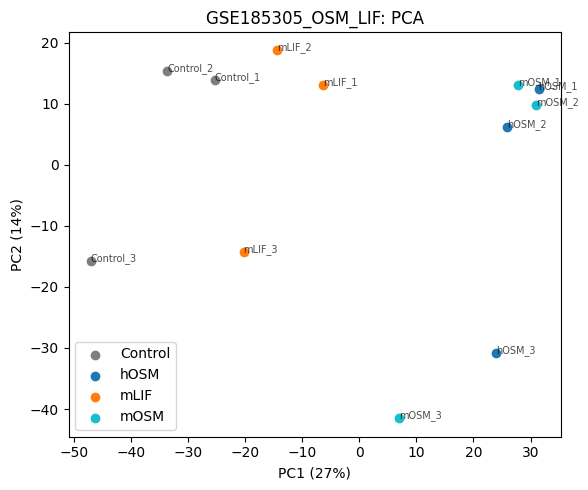

[hosm_vs_control] hOSM vs Control: 2296 significant genes (padj < 0.05; 1253 up, 1043 down); padj NA: 2618
[mosm_vs_control] mOSM vs Control: 1496 significant genes (padj < 0.05; 895 up, 601 down); padj NA: 2989
[lif_vs_control] mLIF vs Control: 161 significant genes (padj < 0.05; 126 up, 35 down); padj NA: 5215
[hosm_vs_mosm] hOSM vs mOSM: 1 significant genes (padj < 0.05; 0 up, 1 down); padj NA: 21


In [12]:
# PCA on log2(normalised counts + 1), top 1000 most variable genes, all groups
norm = pd.DataFrame(dds.layers['normed_counts'], index=counts.index, columns=counts.columns)
logn = np.log2(norm + 1)
top = logn.var(axis=0).sort_values(ascending=False).index[:1000]
X = logn[top] - logn[top].mean(axis=0)
U, S, Vt = np.linalg.svd(X.values, full_matrices=False)
pcs = U * S
var_expl = S**2 / np.sum(S**2)

palette = {'hOSM': 'tab:blue', 'mOSM': 'tab:cyan', 'mLIF': 'tab:orange', 'Control': 'tab:gray'}
fig, ax = plt.subplots(figsize=(6, 5))
for grp in sorted(metadata[group_col].unique()):
    idx = (metadata[group_col] == grp).values
    ax.scatter(pcs[idx, 0], pcs[idx, 1], label=grp, color=palette.get(grp))
for i, name in enumerate(counts.index):
    ax.annotate(name, (pcs[i, 0], pcs[i, 1]), fontsize=7, alpha=0.7)
ax.set_xlabel(f'PC1 ({var_expl[0]:.0%})')
ax.set_ylabel(f'PC2 ({var_expl[1]:.0%})')
ax.set_title(f'{dataset_id}: PCA')
ax.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/{dataset_id}_pca.png', dpi=200)
plt.show()

for name, res in results.items():
    num, ref = contrasts[name]
    sig = res['padj'] < alpha
    print(f'[{name}] {num} vs {ref}: {sig.sum()} significant genes (padj < {alpha}; '
          f'{(sig & (res.log2FoldChange > 0)).sum()} up, {(sig & (res.log2FoldChange < 0)).sum()} down); '
          f'padj NA: {res.padj.isna().sum()}')

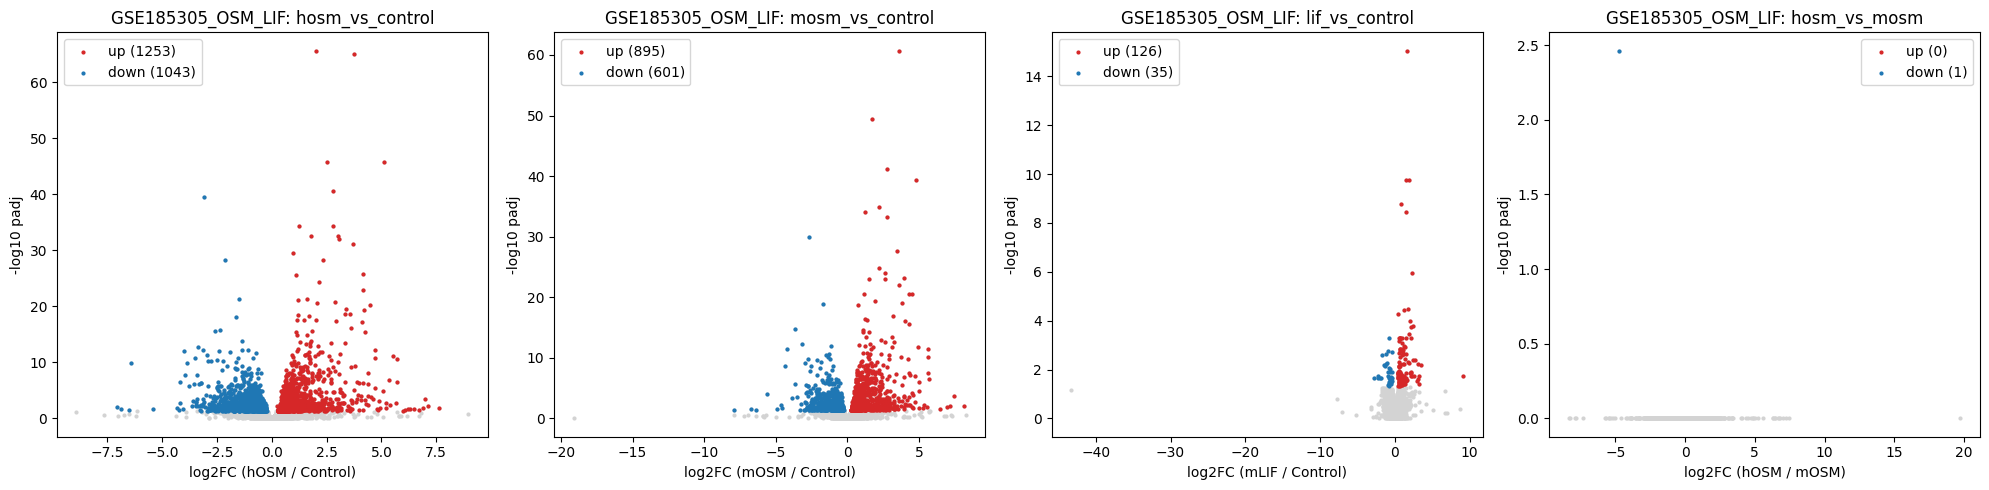

In [13]:
# Volcano plots, one panel per contrast
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5), squeeze=False)
for ax, (name, res) in zip(axes[0], results.items()):
    num, ref = contrasts[name]
    v = res.dropna(subset=['padj']).copy()
    v['neglog10p'] = -np.log10(v['padj'].clip(lower=1e-300))
    up = (v.padj < alpha) & (v.log2FoldChange > 0)
    down = (v.padj < alpha) & (v.log2FoldChange < 0)
    ax.scatter(v.log2FoldChange, v.neglog10p, s=4, color='lightgrey')
    ax.scatter(v.log2FoldChange[up], v.neglog10p[up], s=4, color='tab:red', label=f'up ({up.sum()})')
    ax.scatter(v.log2FoldChange[down], v.neglog10p[down], s=4, color='tab:blue', label=f'down ({down.sum()})')
    ax.set_xlabel(f'log2FC ({num} / {ref})')
    ax.set_ylabel('-log10 padj')
    ax.set_title(f'{dataset_id}: {name}')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/{dataset_id}_volcano.png', dpi=200)
plt.show()

## 6. Export

Writes one table per contrast, `results/<dataset_id>_<contrast>_deseq2.csv` (e.g. `GSE144391_ERBB2_sham_deseq2.csv`, `GSE144391_ERBB2_MI_deseq2.csv`), in the same layout as the AXL DESeq2 table (first column `Gene.name`), plus one settings file.

In [14]:
cols = ['Gene.name', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']
settings = []
for name, res in results.items():
    num, ref = contrasts[name]
    out = res.rename_axis('Gene.name').reset_index()
    out = out[cols].sort_values('padj', na_position='last')
    out_file = f'{results_dir}/{dataset_id}_{name}_deseq2.csv'
    out.to_csv(out_file, index=False)
    print('Saved', out_file, out.shape)
    settings.append({
        'dataset_id': dataset_id, 'contrast_name': name, 'design': design,
        'contrast': f'{num} vs {ref}',
        'n_numerator': int((metadata[group_col] == num).sum()),
        'n_reference': int((metadata[group_col] == ref).sum()),
        'excluded_samples': ','.join(exclude_samples),
        'min_total_counts': min_total_counts, 'n_genes_tested': counts.shape[1],
        'n_sig_padj_lt_alpha': int((res.padj < alpha).sum()), 'pydeseq2': pydeseq2.__version__,
    })

# run settings next to the results, for the cross-dataset comparison
pd.DataFrame(settings).to_csv(f'{results_dir}/{dataset_id}_deseq2_settings.csv', index=False)
pd.DataFrame(settings)

Saved /mnt/sds-hd/sd22b002/projects/ines/axl_networks/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_hosm_vs_control_deseq2.csv (19157, 7)
Saved /mnt/sds-hd/sd22b002/projects/ines/axl_networks/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_mosm_vs_control_deseq2.csv (19157, 7)
Saved /mnt/sds-hd/sd22b002/projects/ines/axl_networks/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_lif_vs_control_deseq2.csv (19157, 7)
Saved /mnt/sds-hd/sd22b002/projects/ines/axl_networks/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_hosm_vs_mosm_deseq2.csv (19157, 7)


,dataset_id,contrast_name,design,contrast,n_numerator,n_reference,excluded_samples,min_total_counts,n_genes_tested,n_sig_padj_lt_alpha,pydeseq2
0,GSE185305_OSM_LIF,hosm_vs_control,~condition,hOSM vs Control,3,3,,30,19157,2296,0.5.4
1,GSE185305_OSM_LIF,mosm_vs_control,~condition,mOSM vs Control,3,3,,30,19157,1496,0.5.4
2,GSE185305_OSM_LIF,lif_vs_control,~condition,mLIF vs Control,3,3,,30,19157,161,0.5.4
3,GSE185305_OSM_LIF,hosm_vs_mosm,~condition,hOSM vs mOSM,3,3,,30,19157,1,0.5.4
